# Predykcja odejść klientów przy wykorzystaniu sieci neuronowych

In [9]:
import pandas as pd

df = pd.read_csv("data/preprocessed_telco_customer_churn.csv", index_col=0)
df.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,online_security,online_backup,device_protection,...,internet_service_fiber_optic,internet_service_no,contract_month_to_month,contract_one_year,contract_two_year,payment_method_bank_transfer_automatic,payment_method_credit_card_automatic,payment_method_electronic_check,payment_method_mailed_check,churn
customerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,1,0,0
5575-GNVDE,1,0,0,0,34,1,0,1,0,1,...,0,0,0,1,0,0,0,0,1,0
3668-QPYBK,1,0,0,0,2,1,0,1,1,0,...,0,0,1,0,0,0,0,0,1,1
7795-CFOCW,1,0,0,0,45,0,0,1,0,1,...,0,0,0,1,0,1,0,0,0,0
9237-HQITU,0,0,0,0,2,1,0,0,0,0,...,1,0,1,0,0,0,0,1,0,1


#### Podział zbioru na dane treningowe i testowe oraz skalowanie kolumn numerycznych

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=55, stratify=y)

cols_to_scale = ['tenure', 'monthly_charges', 'total_charges']
scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

### Klasyfikator MLP (Multilayer Perceptron)

Zaawansowany algorytm klasyfikacji inspirowany strukturą i działaniem ludzkiego mózgu, należący do grupy modeli uczenia głębokiego (*Deep Learning*).

**Działanie algorytmu:**

* **Struktura warstwowa:** Dane przepływają przez sekwencję warstw: wejściową, jedną lub więcej warstw ukrytych oraz warstwę wyjściową.
* **Przetwarzanie w neuronach:** Każdy neuron w warstwie oblicza sumę ważoną sygnałów z poprzedniej warstwy, a następnie nakłada **funkcję aktywacji** (np. Logistic lub ReLU), co pozwala modelowi wykrywać nieliniowe i złożone zależności w danych.
* **Uczenie (Propagacja wsteczna):** Model minimalizuje błąd prognozy poprzez algorytm wstecznej propagacji błędu, który precyzyjnie koryguje wagi połączeń między neuronami.
* **Optymalizacja:** Proces uczenia jest kontrolowany przez optymalizator (np. Adam), który dba o to, aby sieć z każdą iteracją coraz lepiej dopasowywała się do wzorców w zbiorze treningowym.

In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

mlp = MLPClassifier(max_iter=1000, random_state=55, early_stopping=True)

param_grid = {
    'hidden_layer_sizes': [(64,), (32, 16), (50, 25), (16, 8), (8, 4)],
    'activation': ['relu', 'logistic'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.01, 0.05],
    'learning_rate_init': [0.001, 0.01]
}

grid_mlp = GridSearchCV(mlp, param_grid, cv=skf, scoring='f1')
grid_mlp.fit(X_train, y_train)

best_mlp = grid_mlp.best_estimator_
y_pred = best_mlp.predict(X_test)

print("--- MLP ---")
print(f"Najlepsze parametry: {grid_mlp.best_params_}")
print(f"Best F1 score (train): {grid_mlp.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nReport:")
print(classification_report(y_test, y_pred))

--- MLP ---
Najlepsze parametry: {'activation': 'logistic', 'alpha': 0.05, 'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.01, 'solver': 'adam'}
Best F1 score (train): 0.5987
Test accuracy: 0.8112

Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1035
           1       0.72      0.47      0.57       374

    accuracy                           0.81      1409
   macro avg       0.78      0.70      0.72      1409
weighted avg       0.80      0.81      0.80      1409



Model MLP przy domyślnym progu decyzyjnym uzyskał wskaźnik F1-score na poziomie 0.57 dla klasy osób odchodzących. Wysoka precyzja (Precision: 0.72) wskazuje na dużą wiarygodność generowanych alertów, jednak czułość (Recall: 0.47) oznacza, że algorytm przy tym ustawieniu poprawnie wykrywa 47% faktycznych przypadków rezygnacji, zachowując ogólną dokładność klasyfikacji (Accuracy) na poziomie 81.1%.

In [12]:
import numpy as np
from sklearn.metrics import precision_recall_curve

y_probs = best_mlp.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores)]

y_pred_adj = (y_probs >= best_threshold).astype(int)

print(f"--- MLP with best threshold ({best_threshold:.2f}) ---")
print(f"New F1-score: {max(f1_scores):.4f}")
print("\nReport:")
print(classification_report(y_test, y_pred_adj))

--- MLP with best threshold (0.22) ---
New F1-score: 0.6580

Report:
              precision    recall  f1-score   support

           0       0.92      0.77      0.83      1035
           1       0.56      0.81      0.66       374

    accuracy                           0.78      1409
   macro avg       0.74      0.79      0.75      1409
weighted avg       0.82      0.78      0.79      1409



Model MLP po optymalizacji progu decyzyjnego do poziomu 0.22 uzyskał wysoki balans metryk, osiągając wskaźnik F1-score na poziomie 0.6580 dla klasy osób odchodzących. Wysoka czułość (Recall: 0.81) oznacza, że algorytm poprawnie zidentyfikował 81% wszystkich faktycznych przypadków rezygnacji, przy zachowaniu ogólnej dokładności klasyfikacji (Accuracy) na poziomie 78%.

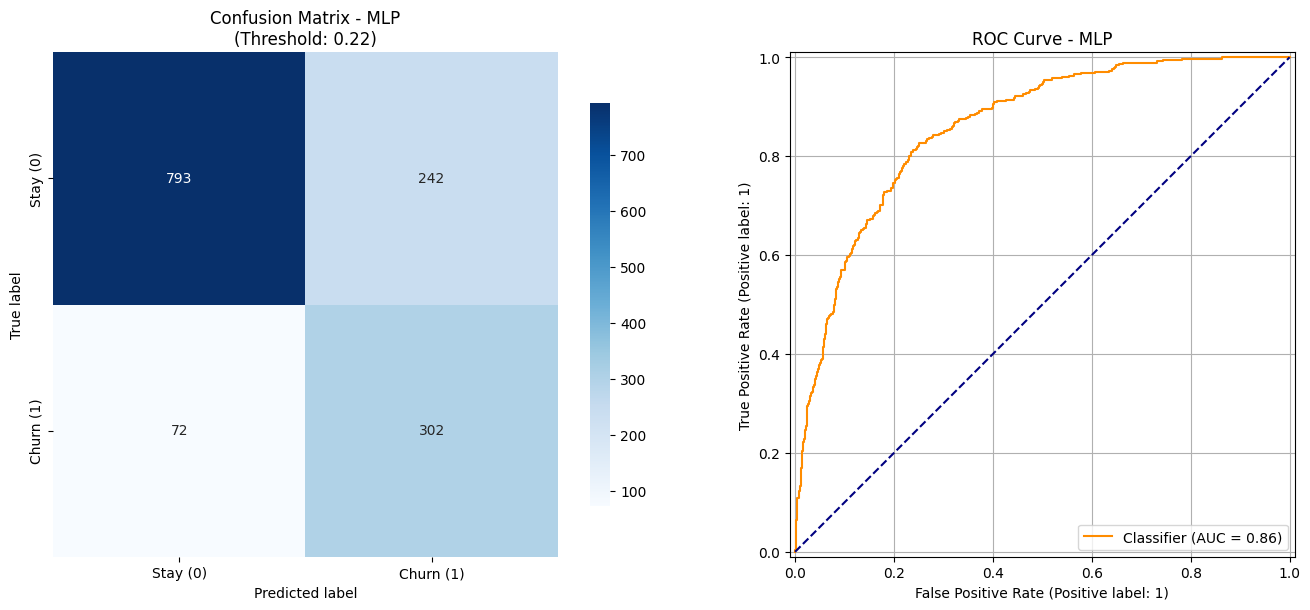

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, RocCurveDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

cm = confusion_matrix(y_test, y_pred_adj)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True, cbar_kws={"shrink": .8},
            xticklabels=['Stay (0)', 'Churn (1)'], 
            yticklabels=['Stay (0)', 'Churn (1)'], ax=ax1)
ax1.set_xlabel('Predicted label')
ax1.set_ylabel('True label')
ax1.set_title(f'Confusion Matrix - MLP\n(Threshold: {best_threshold:.2f})')

RocCurveDisplay.from_predictions(y_test, y_probs, ax=ax2, color='darkorange')
ax2.plot([0, 1], [0, 1], color='navy', linestyle='--')
ax2.set_title('ROC Curve - MLP')
ax2.set_aspect('equal')
ax2.grid(True)

plt.tight_layout()
plt.show()

Wykres macierzy konfuzji pokazuje, że model poprawnie zidentyfikował 302 osoby faktycznie odchodzące oraz 793 lojalnych klientów. Błąd typu II wystąpił w 72 przypadkach, co oznacza, że algorytm skutecznie wyłapuje większość realnych rezygnacji, choć generuje przy tym zauważalną liczbę błędnych wskazań w grupie stabilnych klientów.

Wykres krzywej ROC z wynikiem AUC na poziomie 0.86 potwierdza wysoką skuteczność modelu w rozróżnianiu obu grup użytkowników. Wynik ten wskazuje, że MLP z dużym prawdopodobieństwem poprawnie różnicuje sygnały świadczące o chęci odejścia od zachowań typowych dla osób pozostających w firmie.